In [12]:
import io # Import for handling input/output operations
from io import StringIO # allows you to treat strings as file-like objects
import ee # Imports the Earth Engine API functionality
import pandas as pd # Import the pandas functionality
import geopandas as gpd # Import the geopandas functionality
from sklearn.cluster import KMeans # Import KMeans
import matplotlib.pyplot as plt # Import for plotting
from clustergram import Clustergram # Import for visualising cluster structure
import numpy as np # Import for numerical operations
from IPython.display import Image, display # Import image and display utilities
import duckdb # Enables duckdb functionality
import plotly.express as px # Import for interactive plotting and visualisation
import umap # Import for dimensionality reduction using UMAP
import seaborn as sns # Import for statistical data visualisation
import requests # Import for making HTTP requests
from PIL import Image as PILImage # Import PIL Image functionality
import os # Import for operating system interface
from sklearn.ensemble import RandomForestClassifier # Import Random Forest classifier
from sklearn.model_selection import train_test_split # Import for splitting datasets
from sklearn.metrics import classification_report, confusion_matrix # Import for model evaluation metrics

In [13]:
import ee
ee.Authenticate()

True

In [4]:
# Initialise Earth Engine (this project is called - alpha-tutorial-477812)
ee.Initialize(project='ee-anzonyquispe') # You may also need to specify your project, e.g. ee.Initialize(project='your_project_ID_here')

In [6]:
# Buildings property locations
# Read the GeoParquet file containing building locations
main_path = "/Users/anzony.quisperojas/Downloads/tutorial_data"
buildings = gpd.read_parquet(f'{main_path}/lcrca_buildings.parquet')

# Convert buildings to WGS84 coordinate system (EPSG:4326)
buildings = buildings.to_crs(epsg=4326)
buildings["lon"] = buildings.geometry.x
buildings["lat"] = buildings.geometry.y
# Read GeoPackage into a GeoDataFrame and convert to WGS84 (EPSG:4326)
lcrca = gpd.read_file(f'{main_path}/lcrca.gpkg')

# Reproject to WGS84
lcrca = lcrca.to_crs(epsg=4326)

# Get the boundary coordinates
coords = lcrca.geometry.iloc[0].__geo_interface__

# Convert to Earth Engine geometry
lcrca_geometry = ee.Geometry(coords)

# Access the embedding collection
embedding_collection = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')

# Work with each year separately
years = range(2017, 2025) 
year_images = {}

# Loop through each year from 2017 to 2024 that overlap with the LCRCA boundary
for year in years:
  year_filtered = embedding_collection \
    .filterDate(f'{year}-01-01', f'{year}-12-31') \
    .filterBounds(lcrca_geometry)
  
  # Check if any images exist for this year (avoid processing empty collections)
  if year_filtered.size().getInfo() > 0:
    # Create a mosaic from all filtered images and clip to the LCRCA boundary
    year_images[year] = year_filtered.mosaic().clip(lcrca_geometry)
# Select 2024 as the year
emb_img = year_images[2024]

# Calculate the total number of pixels in the region
pixel_count = emb_img.select(0).reduceRegion(
  reducer=ee.Reducer.count(),      # Count the number of valid pixels
  geometry=lcrca_geometry,         # Within the LCRCA boundary
  scale=10,                        # At 10-meter resolution
  maxPixels=1e9                    # Allow up to 1 billion pixels to be processed
)

# Get and print the count
total_pixels = pixel_count.getInfo()
total_count = list(total_pixels.values())[0]

print(f"Total pixels in region at 10m scale: {total_count:,}")

Total pixels in region at 10m scale: 12,259,151


In [7]:
# LCRCA_Samples = duckdb.sql(f"SELECT * FROM read_csv_auto('/Users/anzony.quisperojas/Downloads/tutorial_data/lcrca_samples_batch_*.csv')").df() # Create a single DataFrame
# LCRCA_Samples = LCRCA_Samples.iloc[:, 1:-1] # Remove the first and last column
# LCRCA_Samples.to_parquet('./data/LCRCA_Samples.parquet') # Export to a parquet

In [16]:
LCRCA_Samples = pd.read_parquet(f'{main_path}/LCRCA_Samples.parquet')

## Clustergram

How cluster members are assigned to clusters as the number of cluster increases. 

<Axes: xlabel='Number of clusters (k)', ylabel='PCA weighted mean of the clusters'>

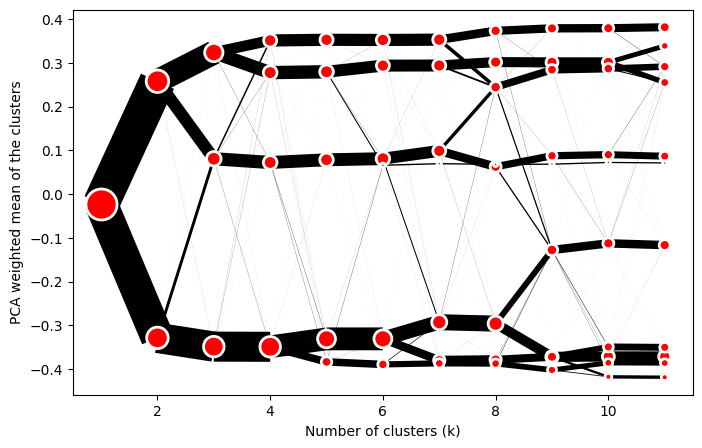

In [17]:
# Create clustergram to visualise optimal number of clusters
cgram = Clustergram(range(1, 12), init="random", n_init=10, random_state=42, verbose=False)
cgram.fit(LCRCA_Samples)

cgram.plot(figsize=(8, 5))

In [ ]:
# Sample pixels across the region - this builds an initial training model which is then applied to all pixels
training = emb_img.sample(
  region=lcrca_geometry,        # Sample within the LCRCA boundary
  scale=10,                     # Use 10-meter pixel resolution (matches embedding data)
  numPixels=100000,             # Extract 100,000 random pixels for training
  seed=42                       # Set random seed for reproducible sampling
)

# Train K-Means with 5 clusters
clusterer = ee.Clusterer.wekaKMeans(5).train(training)

# Apply to the image
result = emb_img.cluster(clusterer).clip(lcrca_geometry)

# Define the same colours for visualisation
cluster_colours = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

# Create a palette for the clusters (GEE format)
palette = cluster_colours

# Set visualisation parameters
vis_params = {
    'min': 0,
    'max': 4,
    'palette': palette
}

# Export as static image
url = result.getThumbURL({
    'dimensions': 1024,  # Image width/height in pixels
    'region': lcrca_geometry,
    'min': 0,
    'max': 4,
    'palette': palette,
    'format': 'png',
    'crs': 'EPSG:27700'
})

# Download the image locally
response = requests.get(url)
response.raise_for_status()  # Raise an exception for bad status codes


FileNotFoundError: [Errno 2] No such file or directory: './images/lcrca_clusters.png'

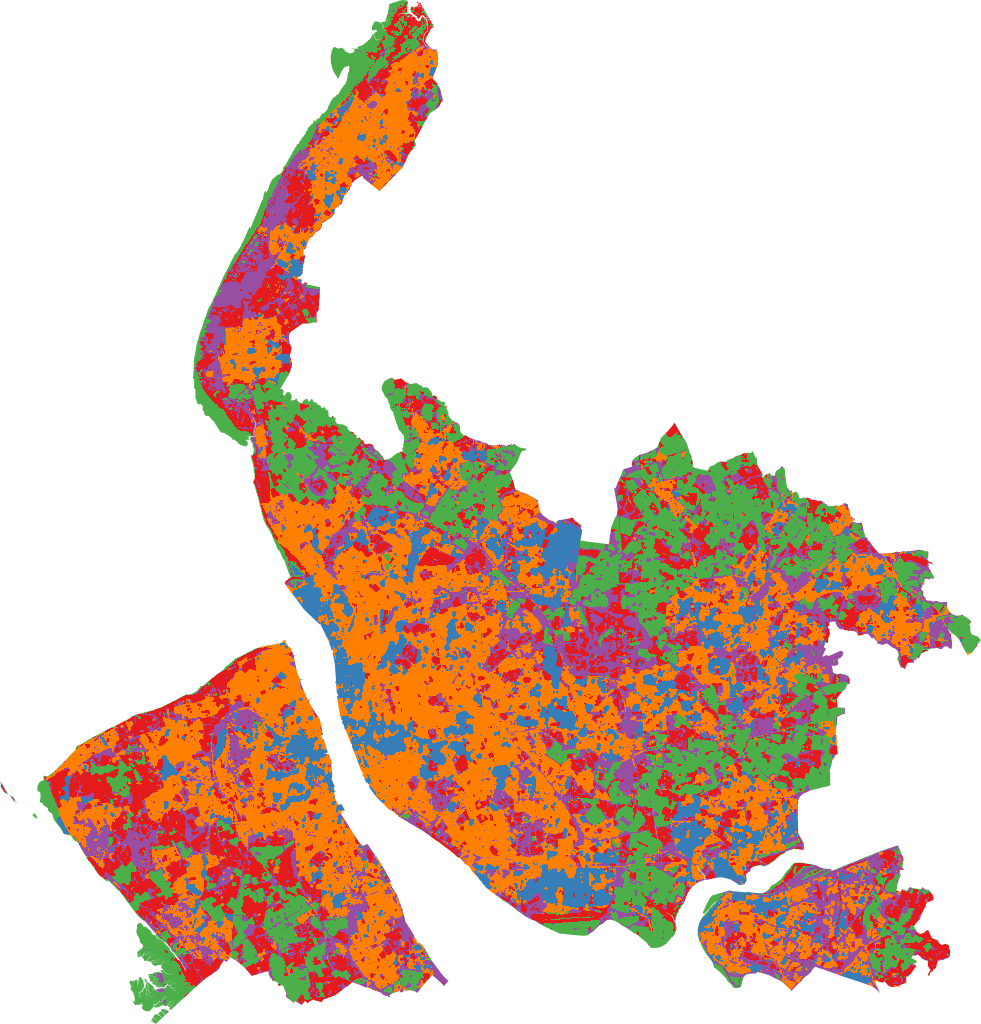

In [21]:

# Create a local filename
local_filename = "/Users/anzony.quisperojas/Downloads/lcrca_clusters.png"

# Save the image locally
with open(local_filename, 'wb') as f:
    f.write(response.content)

# Display the local image
display(Image(filename=local_filename, width=750))

## Clustering at building level

In [ ]:
# Parameters
year = 2024
batch_size = 1000   # batch size

# Get embedding image
embedding_collection = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
embedding_image = embedding_collection.filterDate(f"{year}-01-01", f"{year}-12-31").mosaic()

# Storage for results
all_results = []

# Split into batches
n_batches = int(np.ceil(len(buildings) / batch_size))
print(f"Total points: {len(buildings)}, processing in {n_batches} batches of {batch_size}")

for i in range(n_batches):
    # Select the current batch of buildings for processing
    start = i * batch_size
    end = min((i + 1) * batch_size, len(buildings))
    batch = buildings.iloc[start:end]

    print(f"Processing batch {i+1}/{n_batches} with {len(batch)} points...")

    # Build FeatureCollection
    features = []  # Initialise an empty list to store Earth Engine features
    for idx, row in batch.iterrows():  # Iterate over each row
      point = ee.Geometry.Point([row['lon'], row['lat']])  # Create a Point geometry
      feature = ee.Feature(point, {"index": idx})  # Create an Earth Engine Feature
      features.append(feature)  # Add the feature to the list

    # Convert the list of features to an Earth Engine FeatureCollection
    fc = ee.FeatureCollection(features)

    # Extract embeddings for each building point in the batch
    extracted = embedding_image.reduceRegions(
      collection=fc,                # The FeatureCollection of building points
      reducer=ee.Reducer.first(),   # Extract the first value for each embedding band at each point
      scale=10,                     # Use 10-meter pixel resolution (matches embedding data)
      tileScale=4                   # Increase tileScale to handle larger regions and avoid memory errors
    )
  
    # Convert to DataFrame
    results = extracted.getInfo()  # Retrieve the results into a Python dictionary
    embedding_dict = {}  # Initialise an empty dictionary
    for feature in results['features']:  # Iterate over each feature (building point) in the results
      props = feature['properties']  # Extract the properties (embedding values and index) for this feature
      idx = props.pop("index")  # Remove and get the 'index' property (original building index)
      band_values = {k: v for k, v in props.items() if not k.startswith("system:")}  # Filter out system fields, keep only embedding bands
      embedding_dict[idx] = band_values  # Store the embedding values in the dictionary, keyed by building index

    # Convert the embedding_dict (indexed by building index) to a DataFrame
    batch_df = pd.DataFrame.from_dict(embedding_dict, orient="index")
    batch_df.index.name = "index"  # Set the index name for merging with the batch

    # Merge with original batch
    merged = batch.reset_index().merge(batch_df, left_on="index", right_index=True, how="left").drop(columns="index")
    all_results.append(merged)

# Combine all batches
result = pd.concat(all_results, ignore_index=True)

# Output parquet file
result.to_parquet('./data/buildings_with_embeddings.parquet', index=False)

In [9]:
buildings_with_embeddings = pd.read_parquet(f'{main_path}/buildings_with_embeddings.parquet')

<Axes: xlabel='Number of clusters (k)', ylabel='PCA weighted mean of the clusters'>

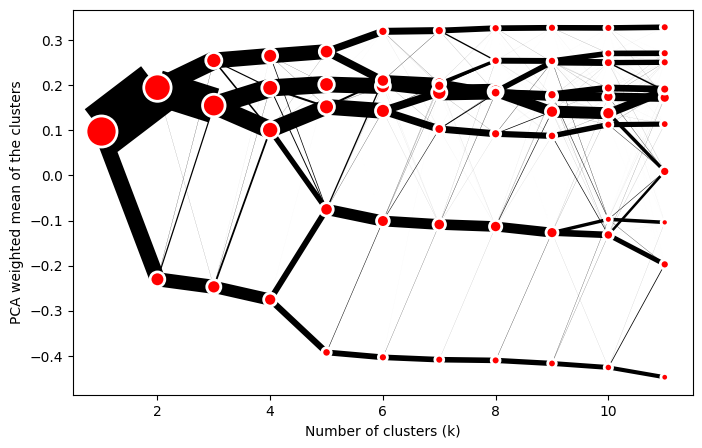

In [10]:
# Create clustergram to visualise optimal number of clusters
embedding_cols = [f"A{str(i).zfill(2)}" for i in range(64)]
cgram = Clustergram(range(1, 12), n_init=10, random_state=42, verbose=False)
cgram.fit(buildings_with_embeddings[embedding_cols])

cgram.plot(figsize=(8, 5))

In [11]:
# Fit K-Means with 5 clusters and 1000 initialisations
kmeans = KMeans(n_clusters=5, init="random", n_init=1000, random_state=42)
labels = kmeans.fit_predict(buildings_with_embeddings[embedding_cols])

# Map numeric labels to letters
label_map = {i: chr(65 + i) for i in range(5)}  # 0->A, 1->B, etc.
letter_labels = [label_map[label] for label in labels]

# Create output table with TOID and assigned cluster letter
output_table = buildings_with_embeddings[['TOID']].copy()
output_table['cluster'] = letter_labels

output_table.to_parquet('./data/output_table.parquet', index=False) # Export the clustering results

KeyboardInterrupt: 

In [ ]:
# Create a GeoDataFrame with the clustering results
gdf = gpd.GeoDataFrame(
  buildings_with_embeddings[['TOID', 'lon', 'lat']].copy(),
  geometry=gpd.points_from_xy(buildings_with_embeddings['lon'], buildings_with_embeddings['lat']),
  crs="EPSG:4326"
)

# Merge with output_table on TOID
gdf = gdf.merge(output_table, on='TOID', how='left')

In [ ]:
gdf.to_file('/Users/anzony.quisperojas/Downloads/buildings_with_clusters.gpkg', layer='buildings_clusters', driver='GPKG')

In [ ]:
# Prepare a DataFrame for UMAP visualisation:
umap_DF = buildings_with_embeddings[[f"A{str(i).zfill(2)}" for i in range(64)] + ["TOID"]].merge(
  gdf[["TOID", "cluster"]], on="TOID", how="left"
)

In [ ]:
# Extract the 64 embedding columns
embedding_cols = [f"A{str(i).zfill(2)}" for i in range(64)]
embeddings_data = umap_DF[embedding_cols].values

# Apply UMAP to reduce 64 dimensions to 2D
umap_reducer = umap.UMAP(
    n_neighbors=30,        # Numbers of neighbours
    min_dist=0.0,          # Allow points to be closer together
    n_components=2,        # Reduce to 2D for visualsation
    random_state=42,       # For reproducible results
    metric='cosine',       # Cosine similarity works well for embeddings
    init='random',         # Use random initialisation
    n_epochs=500,          # More epochs for better convergence
    spread=1.0,            # Controls how tightly points are packed
    verbose=False          # Show progress
)

# Fit UMAP and transform the data
umap_embedding = umap_reducer.fit_transform(embeddings_data)

# Create a DataFrame with UMAP coordinates and existing cluster labels
umap_results = pd.DataFrame({
    'UMAP1': umap_embedding[:, 0],
    'UMAP2': umap_embedding[:, 1],
    'Cluster': umap_DF['cluster'],  # Use existing cluster column
    'TOID': umap_DF['TOID']        # Use existing TOID column
})

# Save the UMAP results
umap_results.to_parquet('./data/buildings_umap_results.parquet', index=False)

In [ ]:
umap_results = pd.read_parquet(f'{main_path}/buildings_umap_results.parquet')
# Define colours for each cluster - match the earlier map
colours = {
    'A': '#8dd3c7',
    'B': '#ffffb3', 
    'C': '#bebada',
    'D': '#fb8072',
    'E': '#80b1d3'
}

# Create interactive plot
fig_interactive = px.scatter(
    umap_results, 
    x='UMAP1', 
    y='UMAP2', 
    color='Cluster',
    color_discrete_map=colours,
    hover_data=['TOID']
)
fig_interactive.update_traces(marker=dict(size=2, opacity=0.7))
fig_interactive.show()

In [ ]:
# Cluster statistics
cluster_stats = (
    umap_results['Cluster']
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Count")
)
cluster_stats["Percentage"] = (cluster_stats["Count"] / len(umap_results) * 100).round(1)

# Cluster separation in UMAP space
cluster_centres_umap = (
    umap_results.groupby("Cluster")[["UMAP1", "UMAP2"]]
    .mean()
    .reset_index()
    .rename(columns={"UMAP1": "Centre UMAP1", "UMAP2": "Centre UMAP2"})
    .round(2)
)

# Merge both summaries into one table
cluster_summary = pd.merge(cluster_stats, cluster_centres_umap, on="Cluster")

# Display the results
cluster_summary.style.hide(axis='index').format({
    'Percentage': '{:.1f}',
    'Centre UMAP1': '{:.2f}',
    'Centre UMAP2': '{:.2f}',
    'Count': '{:d}'  # Keep count as integer
})

## Matching Building Characteristics


In [8]:
# Load EPC-derived building characteristics for each TOID
TOID_EPC_characteristics = pd.read_parquet(f'{main_path}/TOID_EPC_characteristics.parquet') 

# Recode BUILT_FORM values
TOID_EPC_characteristics['BUILT_FORM'] = TOID_EPC_characteristics['BUILT_FORM'].replace({
  'Mid-Terrace': 'Terrace',
  'End-Terrace': 'Terrace',
  'Enclosed Mid-Terrace': 'Terrace',
  'Enclosed End-Terrace': 'Terrace',
  'NO DATA!': None
})

# Simple recoding of CONSTRUCTION_AGE_BAND column
TOID_EPC_characteristics['CONSTRUCTION_AGE_BAND'] = TOID_EPC_characteristics['CONSTRUCTION_AGE_BAND'].replace({
    # No data
    'NO DATA!': None,
    'INVALID!': None,
    
    # Pre-1900
    'before 1900': '1900 or earlier',
  
    # All 1900-1929
    '1900': '1900-1929',
    '1900-1929': '1900-1929',
    
    # All 1983-1995
    '1983-1990': '1983-1995',
    '1991-1995': '1983-1995',
    
    # 2003 onwards
    '2003-2006': '2003 onwards',
    '2007': '2003 onwards',
    '2007-2011': '2003 onwards', 
    '2008': '2003 onwards',
    '2007 onwards': '2003 onwards',
    '2009': '2003 onwards',
    '2010': '2003 onwards',
    '2012': '2003 onwards',
    '2012 onwards': '2003 onwards',
    '2013': '2003 onwards',
    '2014': '2003 onwards',
    '2015': '2003 onwards',
    '2016': '2003 onwards',
    '2017': '2003 onwards',
    '2018': '2003 onwards',
    '2019': '2003 onwards',
    '2020': '2003 onwards',
    '2021': '2003 onwards',
    '2022': '2003 onwards',
    '2023': '2003 onwards',
    '2024': '2003 onwards',
    '2025': '2003 onwards'
})

In [ ]:
# Merge EPC-derived building characteristics into UMAP results using TOID
output_table = output_table.merge(TOID_EPC_characteristics, on="TOID", how="left")

In [ ]:
# Calculate overall proportion for each built form
overall_props = output_table['BUILT_FORM'].value_counts(normalize=True)

# Calculate cluster-specific proportions
cluster_props = output_table.groupby('cluster')['BUILT_FORM'].value_counts(normalize=True).unstack(fill_value=0)

# Calculate propensity index (cluster proportion / overall proportion)
propensity_index = cluster_props.div(overall_props, axis=1)

# Plot heatmap of propensity index
plt.figure(figsize=(8, 5))
sns.heatmap(propensity_index, annot=True, fmt='.2f', cmap='RdBu_r', center=1, 
            cbar_kws={'label': 'Propensity Index (1.0 = average)'})
plt.xlabel('Built Form')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()